In [1]:

# Cell 1 - Load Dataset


from pathlib import Path
import pandas as pd
import numpy as np


# Path to our CSV file
DATA_PATH = Path(
    r"CycloneGuard_Bay_of_Bengal_India_Enhanced_Real_Dataset.csv"
)


# Check that the file exists
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH}"
    )


# Load the CSV
df = pd.read_csv(
    DATA_PATH,
    low_memory=False
)


# Display basic information
print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

Dataset loaded successfully.
Rows    : 35,829
Columns : 92


In [2]:
# ============================================================
# CycloneGuard AI
# Cell 2 - Dataset Overview
# ============================================================

# ------------------------------------------------------------
# 1. Basic shape
# ------------------------------------------------------------

print("DATASET SHAPE")
print("-" * 50)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")


# ------------------------------------------------------------
# 2. First 5 rows
# ------------------------------------------------------------

print("\nFIRST 5 ROWS")
print("-" * 50)

display(df.head())


# ------------------------------------------------------------
# 3. Column names
# ------------------------------------------------------------

print("\nCOLUMN NAMES")
print("-" * 50)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")


# ------------------------------------------------------------
# 4. Target variables
# ------------------------------------------------------------

print("\nTARGET VARIABLES")
print("-" * 50)

target_columns = [
    "target_wind_kts",
    "target_pressure_hpa",
    "target_wind_change_kts",
    "target_pressure_change_hpa"
]

for column in target_columns:

    if column in df.columns:
        print(f"\n{column}")
        print(f"Missing values : {df[column].isna().sum():,}")
        print(f"Available      : {df[column].notna().sum():,}")


# ------------------------------------------------------------
# 5. Forecast horizons
# ------------------------------------------------------------

print("\nFORECAST HORIZONS")
print("-" * 50)

if "forecast_horizon_h" in df.columns:
    print(
        df["forecast_horizon_h"]
        .value_counts()
        .sort_index()
        .to_string()
    )


# ------------------------------------------------------------
# 6. Unique cyclone count
# ------------------------------------------------------------

print("\nCYCLONE INFORMATION")
print("-" * 50)

print(
    f"Unique storm IDs : "
    f"{df['storm_id'].nunique():,}"
)

print(
    f"Years            : "
    f"{df['season'].min()} - {df['season'].max()}"
)


# ------------------------------------------------------------
# 7. Basin distribution
# ------------------------------------------------------------

print("\nBASIN DISTRIBUTION")
print("-" * 50)

print(
    df["basin"]
    .value_counts(dropna=False)
    .to_string()
)


# ------------------------------------------------------------
# 8. Missing-value summary
# ------------------------------------------------------------

print("\nTOP 20 COLUMNS WITH MOST MISSING VALUES")
print("-" * 50)

missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print(missing.to_string())

DATASET SHAPE
--------------------------------------------------
Rows    : 35,829
Columns : 92

FIRST 5 ROWS
--------------------------------------------------


,record_id,record_type,synthetic_record,region,study_bbox,storm_id,storm_name,season,timestamp_utc,latitude,...,impact_reliability,impact_source,forecast_horizon_h,target_time_utc,target_wind_kts,target_pressure_hpa,target_wind_change_kts,target_pressure_change_hpa,source_track_url,source_weather_url
0,2000088N08090_20000327T120000Z_3h,real_track_observation_plus_real_future_target,False,Bay of Bengal project study region,"5-30N, 75-105E",2000088N08090,NaN,2000,2000-03-27T12:00:00Z,7.5,...,NaN,NaN,3,2000-03-27T15:00:00Z,25.0,1005.0,0.0,1.0,https://www.ncei.noaa.gov/data/international-b...,https://archive-api.open-meteo.com/v1/archive
1,2000088N08090_20000327T120000Z_6h,real_track_observation_plus_real_future_target,False,Bay of Bengal project study region,"5-30N, 75-105E",2000088N08090,NaN,2000,2000-03-27T12:00:00Z,7.5,...,NaN,NaN,6,2000-03-27T18:00:00Z,25.0,1006.0,0.0,2.0,https://www.ncei.noaa.gov/data/international-b...,https://archive-api.open-meteo.com/v1/archive
2,2000088N08090_20000327T120000Z_9h,real_track_observation_plus_real_future_target,False,Bay of Bengal project study region,"5-30N, 75-105E",2000088N08090,NaN,2000,2000-03-27T12:00:00Z,7.5,...,NaN,NaN,9,2000-03-27T21:00:00Z,25.0,1005.0,0.0,1.0,https://www.ncei.noaa.gov/data/international-b...,https://archive-api.open-meteo.com/v1/archive
3,2000088N08090_20000327T120000Z_12h,real_track_observation_plus_real_future_target,False,Bay of Bengal project study region,"5-30N, 75-105E",2000088N08090,NaN,2000,2000-03-27T12:00:00Z,7.5,...,NaN,NaN,12,2000-03-28T00:00:00Z,25.0,1004.0,0.0,0.0,https://www.ncei.noaa.gov/data/international-b...,https://archive-api.open-meteo.com/v1/archive
4,2000088N08090_20000327T120000Z_18h,real_track_observation_plus_real_future_target,False,Bay of Bengal project study region,"5-30N, 75-105E",2000088N08090,NaN,2000,2000-03-27T12:00:00Z,7.5,...,NaN,NaN,18,2000-03-28T06:00:00Z,25.0,1005.0,0.0,1.0,https://www.ncei.noaa.gov/data/international-b...,https://archive-api.open-meteo.com/v1/archive



COLUMN NAMES
--------------------------------------------------
01. record_id
02. record_type
03. synthetic_record
04. region
05. study_bbox
06. storm_id
07. storm_name
08. season
09. timestamp_utc
10. latitude
11. longitude
12. basin
13. subbasin
14. storm_type
15. track_type
16. distance_to_land_source
17. landfall_indicator
18. storm_speed_kts
19. storm_direction_deg
20. wmo_wind_kts
21. wmo_pressure_hpa
22. imd_newdelhi_wind_kts
23. imd_newdelhi_pressure_hpa
24. imd_grade
25. imd_ci
26. imd_dp
27. imd_poci_hpa
28. usa_wind_kts
29. usa_pressure_hpa
30. usa_sshs
31. usa_rmw_source
32. usa_roci_source
33. usa_poci_hpa
34. usa_r34_ne_source
35. usa_r34_se_source
36. usa_r34_sw_source
37. usa_r34_nw_source
38. usa_r50_ne_source
39. usa_r50_se_source
40. usa_r50_sw_source
41. usa_r50_nw_source
42. usa_r64_ne_source
43. usa_r64_se_source
44. usa_r64_sw_source
45. usa_gust_source
46. usa_sea_height_source
47. usa_searad_ne_source
48. usa_searad_se_source
49. usa_searad_sw_source
50. usa_s

In [3]:
# ============================================================
# CycloneGuard AI
# Cell 3 - Define the ML Target
# ============================================================

# ------------------------------------------------------------
# 1. Select the target
# ------------------------------------------------------------

TARGET = "target_wind_kts"

print("Selected target:")
print(TARGET)


# ------------------------------------------------------------
# 2. Check target statistics
# ------------------------------------------------------------

print("\nTARGET STATISTICS")
print("-" * 50)

print(df[TARGET].describe())


# ------------------------------------------------------------
# 3. Check missing target values
# ------------------------------------------------------------

missing_target = df[TARGET].isna().sum()

print("\nMISSING TARGET VALUES")
print("-" * 50)

print(
    f"Missing : {missing_target:,}"
)

print(
    f"Available : {df[TARGET].notna().sum():,}"
)


# ------------------------------------------------------------
# 4. Check target distribution by forecast horizon
# ------------------------------------------------------------

print("\nTARGET BY FORECAST HORIZON")
print("-" * 50)

target_by_horizon = (
    df.groupby("forecast_horizon_h")[TARGET]
      .agg(
          count="count",
          mean="mean",
          minimum="min",
          maximum="max"
      )
      .round(2)
)

display(target_by_horizon)


# ------------------------------------------------------------
# 5. Save target definition
# ------------------------------------------------------------

target_definition = {
    "target": TARGET,
    "problem_type": "Regression",
    "description": "Predict future cyclone wind speed in knots"
}

print("\nMODEL PROBLEM")
print("-" * 50)

print("Type        : Regression")
print("Target      :", TARGET)
print("Meaning     : Future cyclone wind speed (knots)")

Selected target:
target_wind_kts

TARGET STATISTICS
--------------------------------------------------
count    34714.000000
mean        37.430921
std         20.988146
min          3.000000
25%         25.000000
50%         30.000000
75%         45.000000
max        150.000000
Name: target_wind_kts, dtype: float64

MISSING TARGET VALUES
--------------------------------------------------
Missing : 1,115
Available : 34,714

TARGET BY FORECAST HORIZON
--------------------------------------------------


,count,mean,minimum,maximum
forecast_horizon_h,,,,
3,5310,35.41,3.0,150.0
6,5113,35.85,3.0,150.0
9,4920,36.28,3.0,150.0
12,4730,36.73,3.0,150.0
18,4375,37.62,3.0,150.0
24,4037,38.52,3.0,150.0
36,3396,40.31,3.0,150.0
48,2833,41.94,3.0,150.0



MODEL PROBLEM
--------------------------------------------------
Type        : Regression
Target      : target_wind_kts
Meaning     : Future cyclone wind speed (knots)


In [4]:
# ============================================================
# CycloneGuard AI
# Cell 4 - Create Leakage-Safe Features
# ============================================================

# ------------------------------------------------------------
# 1. Features available at prediction time
# ------------------------------------------------------------

FEATURES = [
    # Cyclone position
    "latitude",
    "longitude",

    # Time / forecast horizon
    "season",
    "forecast_horizon_h",

    # Cyclone movement
    "storm_speed_kts",
    "storm_direction_deg",
    "movement_distance_from_previous_km",
    "wind_change_from_previous_kts",
    "pressure_change_from_previous_hpa",

    # Current intensity
    "wmo_wind_kts",
    "wmo_pressure_hpa",
    "imd_newdelhi_wind_kts",
    "imd_newdelhi_pressure_hpa",
    "usa_wind_kts",
    "usa_pressure_hpa",

    # Environment
    "weather_elevation_m",
    "temperature_2m_c",
    "relative_humidity_pct",
    "dew_point_2m_c",
    "surface_pressure_hpa",
    "wind_speed_10m_kmh",
    "wind_direction_10m_deg",
    "wind_gusts_10m_kmh",

    # Rainfall
    "precipitation_1h_mm",
    "precipitation_24h_mm",
    "precipitation_72h_mm",
    "precipitation_168h_mm",

    # Land surface
    "soil_moisture_0_7cm_m3m3",

    # Current landfall information
    "landfall_indicator",
    "distance_to_land_source",
]


# ------------------------------------------------------------
# 2. Keep only columns that actually exist
# ------------------------------------------------------------

AVAILABLE_FEATURES = [
    column
    for column in FEATURES
    if column in df.columns
]

MISSING_FEATURES = [
    column
    for column in FEATURES
    if column not in df.columns
]


# ------------------------------------------------------------
# 3. Display feature selection
# ------------------------------------------------------------

print("FEATURE SELECTION")
print("-" * 60)

print(
    f"Requested features : {len(FEATURES)}"
)

print(
    f"Available features : {len(AVAILABLE_FEATURES)}"
)

if MISSING_FEATURES:

    print("\nMissing columns:")

    for column in MISSING_FEATURES:
        print(f"  - {column}")

else:

    print("\n✅ All requested features are available.")


# ------------------------------------------------------------
# 4. Create X and y
# ------------------------------------------------------------

X = df[AVAILABLE_FEATURES].copy()

y = df[TARGET].copy()


# ------------------------------------------------------------
# 5. Remove rows where target is missing
# ------------------------------------------------------------

valid_target = y.notna()

X = X.loc[valid_target].copy()

y = y.loc[valid_target].copy()


# ------------------------------------------------------------
# 6. Basic validation
# ------------------------------------------------------------

print("\nMODEL DATA")
print("-" * 60)

print(
    f"X shape : {X.shape[0]:,} rows × "
    f"{X.shape[1]} features"
)

print(
    f"y shape : {y.shape[0]:,} targets"
)


# ------------------------------------------------------------
# 7. Check for accidental target leakage
# ------------------------------------------------------------

LEAKAGE_COLUMNS = [
    "target_wind_kts",
    "target_pressure_hpa",
    "target_wind_change_kts",
    "target_pressure_change_hpa",
    "target_time_utc",
]

leakage_found = [
    column
    for column in LEAKAGE_COLUMNS
    if column in X.columns
]

print("\nLEAKAGE CHECK")
print("-" * 60)

if leakage_found:

    print("❌ Possible leakage columns found:")
    print(leakage_found)

else:

    print("✅ No target columns are present in X.")


# ------------------------------------------------------------
# 8. Display the selected features
# ------------------------------------------------------------

print("\nSELECTED FEATURES")
print("-" * 60)

for number, feature in enumerate(
    AVAILABLE_FEATURES,
    start=1
):
    print(f"{number:02d}. {feature}")

FEATURE SELECTION
------------------------------------------------------------
Requested features : 30
Available features : 30

✅ All requested features are available.

MODEL DATA
------------------------------------------------------------
X shape : 34,714 rows × 30 features
y shape : 34,714 targets

LEAKAGE CHECK
------------------------------------------------------------
✅ No target columns are present in X.

SELECTED FEATURES
------------------------------------------------------------
01. latitude
02. longitude
03. season
04. forecast_horizon_h
05. storm_speed_kts
06. storm_direction_deg
07. movement_distance_from_previous_km
08. wind_change_from_previous_kts
09. pressure_change_from_previous_hpa
10. wmo_wind_kts
11. wmo_pressure_hpa
12. imd_newdelhi_wind_kts
13. imd_newdelhi_pressure_hpa
14. usa_wind_kts
15. usa_pressure_hpa
16. weather_elevation_m
17. temperature_2m_c
18. relative_humidity_pct
19. dew_point_2m_c
20. surface_pressure_hpa
21. wind_speed_10m_kmh
22. wind_direction

In [5]:
# ============================================================
# CycloneGuard AI
# Cell 5 - Storm-Level Train/Test Split
# ============================================================

from sklearn.model_selection import GroupShuffleSplit


# ------------------------------------------------------------
# 1. Get the cyclone ID for every usable row
# ------------------------------------------------------------

groups = (
    df.loc[X.index, "storm_id"]
    .astype(str)
)


# ------------------------------------------------------------
# 2. Create group-based splitter
# ------------------------------------------------------------
#
# 80% of cyclone groups -> training
# 20% of cyclone groups -> testing
#
# random_state makes the split reproducible.
# ------------------------------------------------------------

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)


# ------------------------------------------------------------
# 3. Generate train/test indices
# ------------------------------------------------------------

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=groups
    )
)


# ------------------------------------------------------------
# 4. Create training and testing datasets
# ------------------------------------------------------------

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()


# ------------------------------------------------------------
# 5. Get storm IDs for validation
# ------------------------------------------------------------

train_storms = set(
    groups.iloc[train_idx]
)

test_storms = set(
    groups.iloc[test_idx]
)


# ------------------------------------------------------------
# 6. Check for overlap
# ------------------------------------------------------------

overlap = train_storms.intersection(
    test_storms
)


# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------

print("TRAIN / TEST SPLIT")
print("-" * 60)

print(
    f"Training rows   : {len(X_train):,}"
)

print(
    f"Testing rows    : {len(X_test):,}"
)

print(
    f"Training storms : {len(train_storms):,}"
)

print(
    f"Testing storms  : {len(test_storms):,}"
)


print("\nSTORM LEAKAGE CHECK")
print("-" * 60)

if len(overlap) == 0:

    print(
        "✅ No storm IDs appear in both "
        "training and testing sets."
    )

else:

    print(
        "❌ Leakage detected!"
    )

    print(
        f"Overlapping storms: {len(overlap)}"
    )


# ------------------------------------------------------------
# 8. Display final shapes
# ------------------------------------------------------------

print("\nFINAL SHAPES")
print("-" * 60)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

TRAIN / TEST SPLIT
------------------------------------------------------------
Training rows   : 27,701
Testing rows    : 7,013
Training storms : 159
Testing storms  : 40

STORM LEAKAGE CHECK
------------------------------------------------------------
✅ No storm IDs appear in both training and testing sets.

FINAL SHAPES
------------------------------------------------------------
X_train : (27701, 30)
X_test  : (7013, 30)
y_train : (27701,)
y_test  : (7013,)


In [6]:
# ============================================================
# CycloneGuard AI
# Cell 6 - Missing Value Preprocessing
# ============================================================

from sklearn.impute import SimpleImputer


# ------------------------------------------------------------
# 1. Create the imputer
# ------------------------------------------------------------
#
# strategy="median":
# Replace a missing value with the median value of that
# feature calculated from the TRAINING data.
#
# add_indicator=True:
# Add an extra binary column for features that had missing
# values. This can help the model learn whether a value was
# originally missing.
# ------------------------------------------------------------

imputer = SimpleImputer(
    strategy="median",
    add_indicator=True
)


# ------------------------------------------------------------
# 2. Fit ONLY on training data
# ------------------------------------------------------------

X_train_processed = imputer.fit_transform(
    X_train
)


# ------------------------------------------------------------
# 3. Apply the same transformation to test data
# ------------------------------------------------------------

X_test_processed = imputer.transform(
    X_test
)


# ------------------------------------------------------------
# 4. Display shapes
# ------------------------------------------------------------

print("PREPROCESSING COMPLETE")
print("-" * 60)

print(
    f"Original training features : "
    f"{X_train.shape[1]}"
)

print(
    f"Processed training features: "
    f"{X_train_processed.shape[1]}"
)

print(
    f"Training samples            : "
    f"{X_train_processed.shape[0]:,}"
)

print(
    f"Testing samples             : "
    f"{X_test_processed.shape[0]:,}"
)


# ------------------------------------------------------------
# 5. Verify no missing values remain
# ------------------------------------------------------------

print("\nMISSING VALUE CHECK")
print("-" * 60)

print(
    f"Training NaN values: "
    f"{__import__('numpy').isnan(X_train_processed).sum():,}"
)

print(
    f"Testing NaN values : "
    f"{__import__('numpy').isnan(X_test_processed).sum():,}"
)


# ------------------------------------------------------------
# 6. Final validation
# ------------------------------------------------------------

if (
    __import__('numpy').isnan(X_train_processed).sum() == 0
    and
    __import__('numpy').isnan(X_test_processed).sum() == 0
):
    print(
        "\n✅ No missing values remain after preprocessing."
    )
else:
    print(
        "\n❌ Missing values still remain."
    )

PREPROCESSING COMPLETE
------------------------------------------------------------
Original training features : 30
Processed training features: 52
Training samples            : 27,701
Testing samples             : 7,013

MISSING VALUE CHECK
------------------------------------------------------------
Training NaN values: 0
Testing NaN values : 0

✅ No missing values remain after preprocessing.


In [7]:
# ============================================================
# CycloneGuard AI
# Cell 7 - Random Forest Baseline Model
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# ------------------------------------------------------------
# 1. Create the Random Forest model
# ------------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 2. Train the model
# ------------------------------------------------------------

print("Training Random Forest...")

rf_model.fit(
    X_train_processed,
    y_train
)

print("✅ Training complete.")


# ------------------------------------------------------------
# 3. Make predictions
# ------------------------------------------------------------

y_pred_rf = rf_model.predict(
    X_test_processed
)


# ------------------------------------------------------------
# 4. Calculate evaluation metrics
# ------------------------------------------------------------

mae = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2 = r2_score(
    y_test,
    y_pred_rf
)


# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"MAE  : {mae:.3f} knots")
print(f"RMSE : {rmse:.3f} knots")
print(f"R²   : {r2:.4f}")

Training Random Forest...
✅ Training complete.

RANDOM FOREST RESULTS
MAE  : 5.207 knots
RMSE : 8.865 knots
R²   : 0.7167


In [8]:
# ============================================================
# CycloneGuard AI
# Cell 8 - Error Analysis by Forecast Horizon
# ============================================================

# Create a table containing the test-set metadata
test_results = df.loc[
    X_test.index,
    [
        "storm_id",
        "forecast_horizon_h"
    ]
].copy()

# Add actual and predicted values
test_results["actual_wind_kts"] = y_test.values
test_results["predicted_wind_kts"] = y_pred_rf

# Calculate absolute error
test_results["absolute_error_kts"] = (
    test_results["actual_wind_kts"]
    - test_results["predicted_wind_kts"]
).abs()


# ------------------------------------------------------------
# Metrics for each forecast horizon
# ------------------------------------------------------------

horizon_results = (
    test_results
    .groupby("forecast_horizon_h")
    .agg(
        samples=("actual_wind_kts", "count"),
        MAE=("absolute_error_kts", "mean"),
        RMSE=(
            "absolute_error_kts",
            lambda x: np.sqrt(np.mean(x ** 2))
        )
    )
    .round(3)
)

print("=" * 60)
print("PERFORMANCE BY FORECAST HORIZON")
print("=" * 60)

display(horizon_results)


# ------------------------------------------------------------
# Best and worst average absolute error
# ------------------------------------------------------------

best_horizon = horizon_results["MAE"].idxmin()
worst_horizon = horizon_results["MAE"].idxmax()

print(f"Lowest MAE horizon : {best_horizon} hours")
print(f"Highest MAE horizon: {worst_horizon} hours")

PERFORMANCE BY FORECAST HORIZON


,samples,MAE,RMSE
forecast_horizon_h,,,
3,1075,2.198,3.431
6,1037,2.750,4.101
9,998,3.346,4.869
12,960,3.976,5.706
18,889,5.320,7.697
24,819,6.607,9.749
36,680,9.809,14.386
48,555,13.210,18.736


Lowest MAE horizon : 3 hours
Highest MAE horizon: 48 hours


TOP 20 FEATURES


,feature,importance
0,usa_wind_kts,0.132442
1,forecast_horizon_h,0.127152
2,usa_pressure_hpa,0.112038
3,imd_newdelhi_wind_kts,0.081429
4,wmo_wind_kts,0.060212
5,imd_newdelhi_pressure_hpa,0.044338
6,wmo_pressure_hpa,0.041124
7,distance_to_land_source,0.026616
8,landfall_indicator,0.025414
9,wind_change_from_previous_kts,0.024094


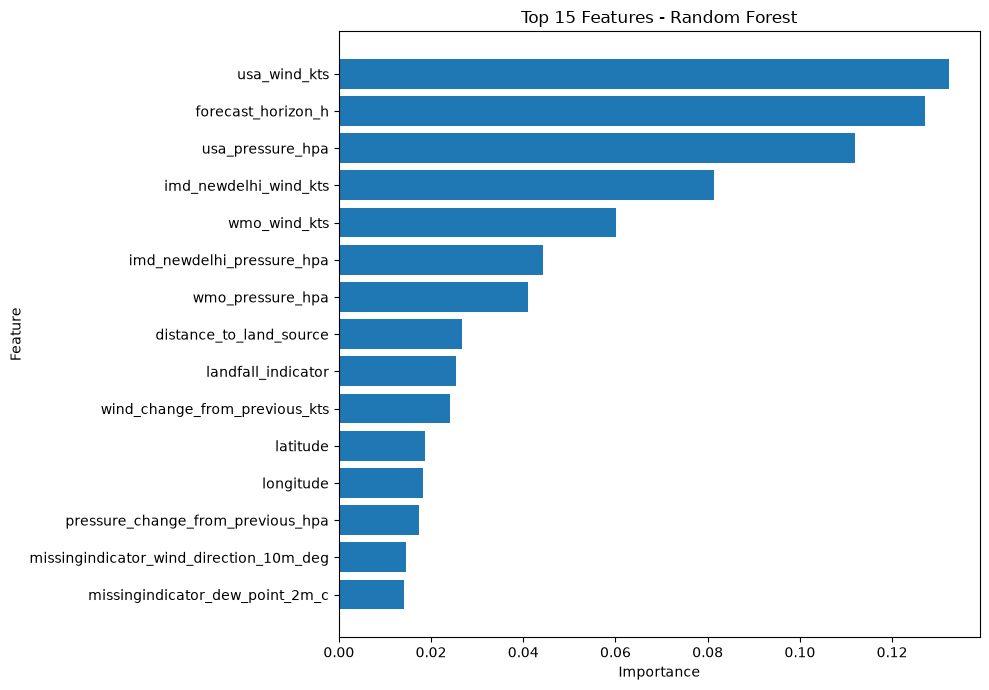

In [9]:
# ============================================================
# CycloneGuard AI
# Cell 9 - Feature Importance
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Get feature importances from Random Forest
# ------------------------------------------------------------

importance_values = rf_model.feature_importances_


# ------------------------------------------------------------
# 2. Create feature names
# ------------------------------------------------------------

# The SimpleImputer added missing-value indicator columns.
# So we need the transformed feature names.

transformed_feature_names = imputer.get_feature_names_out(
    AVAILABLE_FEATURES
)


# ------------------------------------------------------------
# 3. Create importance table
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": importance_values
})


# ------------------------------------------------------------
# 4. Sort from most to least important
# ------------------------------------------------------------

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Display top 20 features
# ------------------------------------------------------------

print("=" * 60)
print("TOP 20 FEATURES")
print("=" * 60)

display(
    feature_importance.head(20)
)


# ------------------------------------------------------------
# 6. Plot top 15 features
# ------------------------------------------------------------

top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "importance"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features - Random Forest"
)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CycloneGuard AI
# Cell 10 - XGBoost Regression Model
# ============================================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# ------------------------------------------------------------
# 1. Create XGBoost model
# ------------------------------------------------------------

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 2. Train the model
# ------------------------------------------------------------

print("Training XGBoost...")

xgb_model.fit(
    X_train_processed,
    y_train
)

print("✅ XGBoost training complete.")


# ------------------------------------------------------------
# 3. Generate predictions
# ------------------------------------------------------------

y_pred_xgb = xgb_model.predict(
    X_test_processed
)


# ------------------------------------------------------------
# 4. Calculate metrics
# ------------------------------------------------------------

xgb_mae = mean_absolute_error(
    y_test,
    y_pred_xgb
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

xgb_r2 = r2_score(
    y_test,
    y_pred_xgb
)


# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("XGBOOST RESULTS")
print("=" * 60)

print(f"MAE  : {xgb_mae:.3f} knots")
print(f"RMSE : {xgb_rmse:.3f} knots")
print(f"R²   : {xgb_r2:.4f}")

Training XGBoost...
✅ XGBoost training complete.

XGBOOST RESULTS
MAE  : 4.883 knots
RMSE : 8.303 knots
R²   : 0.7514


In [11]:
# ============================================================
# CycloneGuard AI
# Cell 11 - XGBoost Performance by Forecast Horizon
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# ------------------------------------------------------------
# 1. Create test-result table
# ------------------------------------------------------------

xgb_results = df.loc[
    X_test.index,
    [
        "storm_id",
        "forecast_horizon_h"
    ]
].copy()


# ------------------------------------------------------------
# 2. Add actual and predicted values
# ------------------------------------------------------------

xgb_results["actual_wind_kts"] = y_test.values
xgb_results["predicted_wind_kts"] = y_pred_xgb


# ------------------------------------------------------------
# 3. Calculate errors
# ------------------------------------------------------------

xgb_results["absolute_error_kts"] = (
    xgb_results["actual_wind_kts"]
    - xgb_results["predicted_wind_kts"]
).abs()

xgb_results["squared_error"] = (
    xgb_results["actual_wind_kts"]
    - xgb_results["predicted_wind_kts"]
) ** 2


# ------------------------------------------------------------
# 4. Calculate metrics by forecast horizon
# ------------------------------------------------------------

horizon_metrics = (
    xgb_results
    .groupby("forecast_horizon_h")
    .agg(
        samples=("actual_wind_kts", "count"),
        MAE=("absolute_error_kts", "mean"),
        RMSE=("squared_error", lambda x: np.sqrt(x.mean()))
    )
    .round(3)
)


# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

print("=" * 60)
print("XGBOOST PERFORMANCE BY FORECAST HORIZON")
print("=" * 60)

display(horizon_metrics)


# ------------------------------------------------------------
# 6. Find highest and lowest MAE
# ------------------------------------------------------------

best_horizon = horizon_metrics["MAE"].idxmin()
worst_horizon = horizon_metrics["MAE"].idxmax()

print(
    f"\nLowest MAE : {best_horizon} hours"
)

print(
    f"Highest MAE: {worst_horizon} hours"
)

XGBOOST PERFORMANCE BY FORECAST HORIZON


,samples,MAE,RMSE
forecast_horizon_h,,,
3,1075,1.760,2.562
6,1037,2.342,3.323
9,998,3.005,4.133
12,960,3.684,5.063
18,889,5.075,7.162
24,819,6.516,9.316
36,680,9.577,13.822
48,555,12.665,17.843



Lowest MAE : 3 hours
Highest MAE: 48 hours


TOP 20 XGBOOST FEATURES


,feature,importance
0,usa_wind_kts,0.185565
1,missingindicator_temperature_2m_c,0.155522
2,missingindicator_relative_humidity_pct,0.153572
3,missingindicator_weather_elevation_m,0.075709
4,usa_pressure_hpa,0.058583
5,precipitation_24h_mm,0.038539
6,wind_speed_10m_kmh,0.036496
7,imd_newdelhi_wind_kts,0.036274
8,precipitation_168h_mm,0.026456
9,precipitation_72h_mm,0.024294


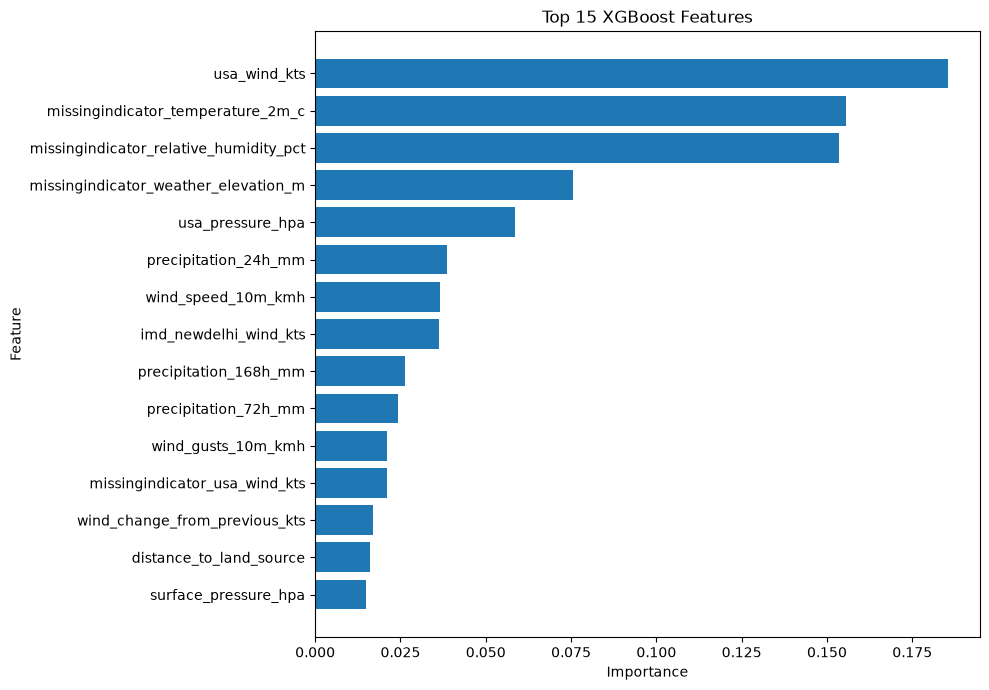

In [12]:
# ============================================================
# CycloneGuard AI
# Cell 12 - XGBoost Feature Importance
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Get XGBoost feature importance
# ------------------------------------------------------------

importance_values = xgb_model.feature_importances_


# ------------------------------------------------------------
# 2. Get transformed feature names
# ------------------------------------------------------------

feature_names = imputer.get_feature_names_out(
    AVAILABLE_FEATURES
)


# ------------------------------------------------------------
# 3. Create importance table
# ------------------------------------------------------------

xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values
})


# ------------------------------------------------------------
# 4. Sort by importance
# ------------------------------------------------------------

xgb_importance = (
    xgb_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Display top 20 features
# ------------------------------------------------------------

print("=" * 60)
print("TOP 20 XGBOOST FEATURES")
print("=" * 60)

display(
    xgb_importance.head(20)
)


# ------------------------------------------------------------
# 6. Plot top 15
# ------------------------------------------------------------

top_features = (
    xgb_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# CycloneGuard AI
# Cell 13 - Leakage-Safe XGBoost Hyperparameter Tuning
# ============================================================

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# ------------------------------------------------------------
# 1. Training data only
# ------------------------------------------------------------

X_train_tune = X_train.copy()
y_train_tune = y_train.copy()

# Storm ID for each training row
groups_train = (
    df.loc[X_train.index, "storm_id"]
    .astype(str)
)


# ------------------------------------------------------------
# 2. Preprocessing + XGBoost pipeline
# ------------------------------------------------------------

tune_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),

    (
        "model",
        XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    )
])


# ------------------------------------------------------------
# 3. Hyperparameter search space
# ------------------------------------------------------------

param_distributions = {
    "model__n_estimators": [
        300, 500, 700, 900
    ],

    "model__learning_rate": [
        0.02, 0.03, 0.05, 0.08
    ],

    "model__max_depth": [
        3, 4, 5, 6, 7
    ],

    "model__min_child_weight": [
        1, 2, 4, 6
    ],

    "model__subsample": [
        0.70, 0.80, 0.90, 1.00
    ],

    "model__colsample_bytree": [
        0.70, 0.80, 0.90, 1.00
    ],

    "model__reg_alpha": [
        0.0, 0.05, 0.10, 0.50
    ],

    "model__reg_lambda": [
        0.5, 1.0, 2.0, 5.0
    ]
}


# ------------------------------------------------------------
# 4. Group-based cross-validation
# ------------------------------------------------------------

group_cv = GroupKFold(
    n_splits=5
)


# ------------------------------------------------------------
# 5. Create randomized search
# ------------------------------------------------------------

search = RandomizedSearchCV(
    estimator=tune_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


# ------------------------------------------------------------
# 6. Start tuning
# ------------------------------------------------------------

print("=" * 60)
print("STARTING XGBOOST HYPERPARAMETER TUNING")
print("=" * 60)

search.fit(
    X_train_tune,
    y_train_tune,
    groups=groups_train
)


# ------------------------------------------------------------
# 7. Best parameters
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BEST XGBOOST PARAMETERS")
print("=" * 60)

for parameter, value in search.best_params_.items():
    print(f"{parameter}: {value}")


# ------------------------------------------------------------
# 8. Best cross-validation score
# ------------------------------------------------------------

best_cv_mae = -search.best_score_

print(
    f"\nBest CV MAE: {best_cv_mae:.3f} knots"
)

STARTING XGBOOST HYPERPARAMETER TUNING
Fitting 5 folds for each of 20 candidates, totalling 100 fits

BEST XGBOOST PARAMETERS
model__subsample: 0.8
model__reg_lambda: 1.0
model__reg_alpha: 0.05
model__n_estimators: 300
model__min_child_weight: 1
model__max_depth: 6
model__learning_rate: 0.03
model__colsample_bytree: 0.8

Best CV MAE: 5.603 knots


In [14]:
# ============================================================
# CycloneGuard AI
# Cell 14 - Evaluate Tuned XGBoost on Unseen Storms
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# ------------------------------------------------------------
# 1. Get the best tuned pipeline
# ------------------------------------------------------------

best_xgb_model = search.best_estimator_


# ------------------------------------------------------------
# 2. Predict on the UNTOUCHED test set
# ------------------------------------------------------------

y_pred_tuned = best_xgb_model.predict(
    X_test
)


# ------------------------------------------------------------
# 3. Calculate metrics
# ------------------------------------------------------------

tuned_mae = mean_absolute_error(
    y_test,
    y_pred_tuned
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned
    )
)

tuned_r2 = r2_score(
    y_test,
    y_pred_tuned
)


# ------------------------------------------------------------
# 4. Compare with the original XGBoost
# ------------------------------------------------------------

print("=" * 60)
print("TUNED XGBOOST - UNTOUCHED TEST SET")
print("=" * 60)

print(f"MAE  : {tuned_mae:.3f} knots")
print(f"RMSE : {tuned_rmse:.3f} knots")
print(f"R²   : {tuned_r2:.4f}")


print("\n" + "=" * 60)
print("ORIGINAL XGBOOST BASELINE")
print("=" * 60)

print(f"MAE  : {xgb_mae:.3f} knots")
print(f"RMSE : {xgb_rmse:.3f} knots")
print(f"R²   : {xgb_r2:.4f}")


print("\n" + "=" * 60)
print("COMPARISON")
print("=" * 60)

print(
    f"MAE change : "
    f"{tuned_mae - xgb_mae:+.3f} knots"
)

print(
    f"RMSE change: "
    f"{tuned_rmse - xgb_rmse:+.3f} knots"
)

print(
    f"R² change  : "
    f"{tuned_r2 - xgb_r2:+.4f}"
)

TUNED XGBOOST - UNTOUCHED TEST SET
MAE  : 4.812 knots
RMSE : 8.191 knots
R²   : 0.7581

ORIGINAL XGBOOST BASELINE
MAE  : 4.883 knots
RMSE : 8.303 knots
R²   : 0.7514

COMPARISON
MAE change : -0.071 knots
RMSE change: -0.112 knots
R² change  : +0.0066


In [15]:
# ============================================================
# CycloneGuard AI
# Cell 15 - Tuned XGBoost Performance by Forecast Horizon
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Create test-result table
# ------------------------------------------------------------

tuned_results = df.loc[
    X_test.index,
    [
        "storm_id",
        "forecast_horizon_h"
    ]
].copy()


# ------------------------------------------------------------
# 2. Add actual and tuned predictions
# ------------------------------------------------------------

tuned_results["actual_wind_kts"] = y_test.values
tuned_results["predicted_wind_kts"] = y_pred_tuned


# ------------------------------------------------------------
# 3. Calculate errors
# ------------------------------------------------------------

tuned_results["absolute_error_kts"] = (
    tuned_results["actual_wind_kts"]
    - tuned_results["predicted_wind_kts"]
).abs()

tuned_results["squared_error"] = (
    tuned_results["actual_wind_kts"]
    - tuned_results["predicted_wind_kts"]
) ** 2


# ------------------------------------------------------------
# 4. Calculate metrics for every horizon
# ------------------------------------------------------------

tuned_horizon_metrics = (
    tuned_results
    .groupby("forecast_horizon_h")
    .agg(
        samples=("actual_wind_kts", "count"),
        MAE=("absolute_error_kts", "mean"),
        RMSE=(
            "squared_error",
            lambda x: np.sqrt(x.mean())
        )
    )
    .round(3)
)


# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

print("=" * 60)
print("TUNED XGBOOST - PERFORMANCE BY FORECAST HORIZON")
print("=" * 60)

display(tuned_horizon_metrics)


# ------------------------------------------------------------
# 6. Display lowest and highest MAE
# ------------------------------------------------------------

print(
    f"\nLowest MAE : "
    f"{tuned_horizon_metrics['MAE'].idxmin()} hours"
)

print(
    f"Highest MAE: "
    f"{tuned_horizon_metrics['MAE'].idxmax()} hours"
)

TUNED XGBOOST - PERFORMANCE BY FORECAST HORIZON


,samples,MAE,RMSE
forecast_horizon_h,,,
3,1075,1.787,2.580
6,1037,2.323,3.260
9,998,2.981,4.082
12,960,3.603,4.995
18,889,5.022,7.180
24,819,6.381,9.172
36,680,9.402,13.646
48,555,12.435,17.524



Lowest MAE : 3 hours
Highest MAE: 48 hours


ERROR ANALYSIS
Mean error       : 0.230 knots
Median error     : 0.206 knots
Mean abs. error  : 4.812 knots


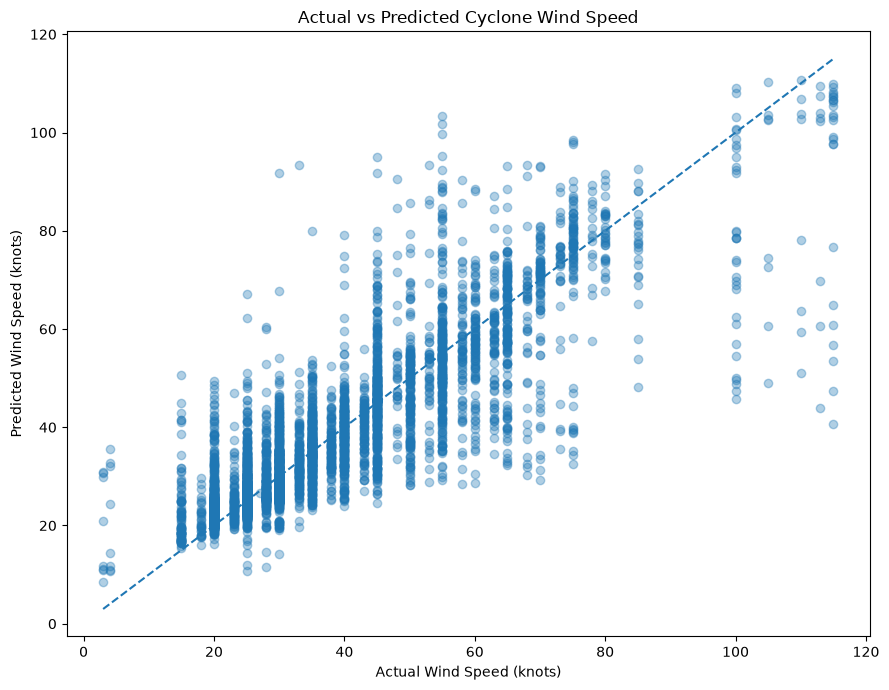

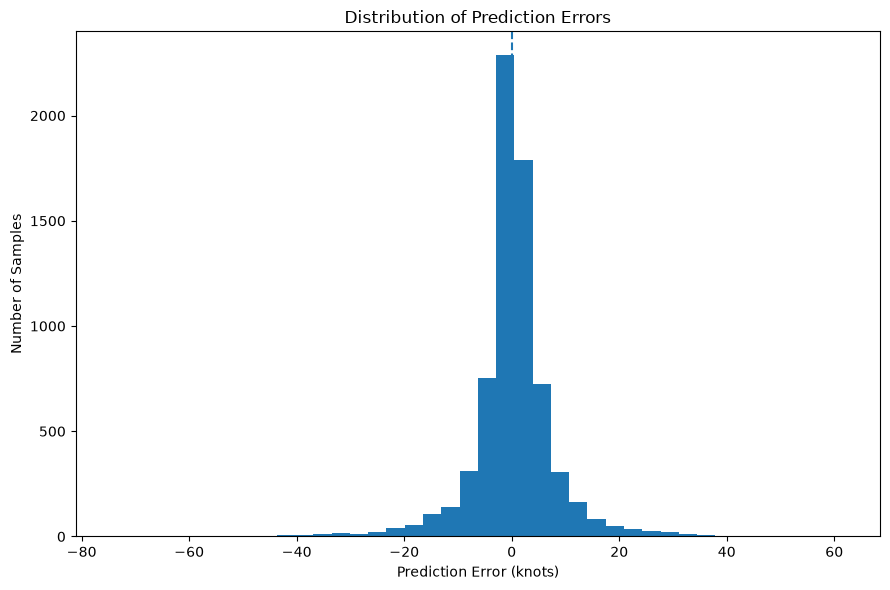

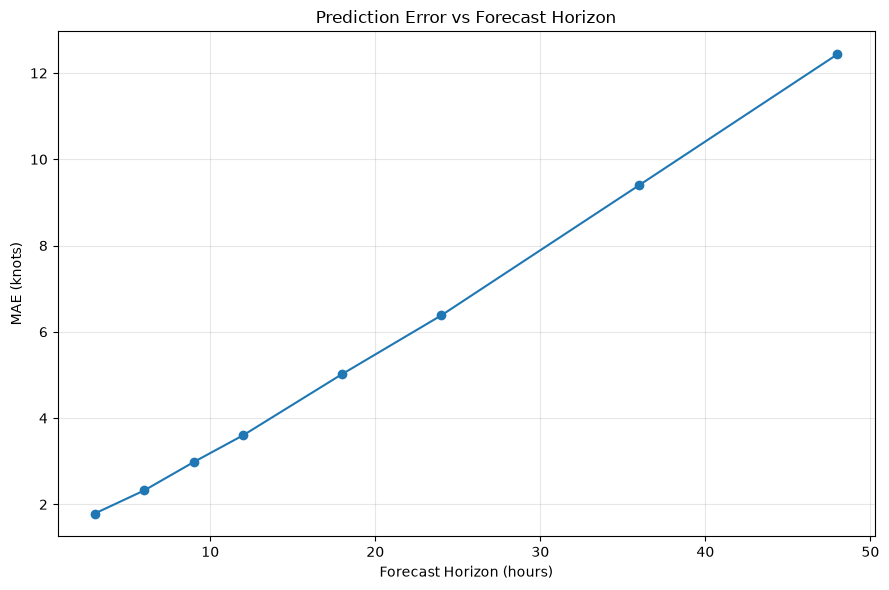


10 LARGEST ABSOLUTE ERRORS


,storm_id,forecast_horizon_h,actual_wind_kts,predicted_wind_kts,error_kts,absolute_error_kts
10621,2008117N11090,48,115.0,40.682991,-74.317009,74.317009
10613,2008117N11090,48,113.0,43.852589,-69.147411,69.147411
10668,2008117N11090,36,115.0,47.385647,-67.614353,67.614353
31113,2022338N05100,48,30.0,91.704605,61.704605,61.704605
10629,2008117N11090,48,115.0,53.391987,-61.608013,61.608013
31105,2022338N05100,48,33.0,93.341774,60.341774,60.341774
10605,2008117N11090,48,110.0,51.085350,-58.914650,58.914650
10637,2008117N11090,48,115.0,56.752064,-58.247936,58.247936
10597,2008117N11090,48,105.0,48.980194,-56.019806,56.019806
10620,2008117N11090,36,100.0,45.707016,-54.292984,54.292984


In [16]:
# ============================================================
# CycloneGuard AI
# Cell 16 - Prediction Error Analysis
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Create prediction-analysis dataframe
# ------------------------------------------------------------

error_df = df.loc[
    X_test.index,
    [
        "storm_id",
        "forecast_horizon_h"
    ]
].copy()

error_df["actual_wind_kts"] = y_test.values
error_df["predicted_wind_kts"] = y_pred_tuned

error_df["error_kts"] = (
    error_df["predicted_wind_kts"]
    - error_df["actual_wind_kts"]
)

error_df["absolute_error_kts"] = (
    error_df["error_kts"].abs()
)


# ------------------------------------------------------------
# 2. Overall error statistics
# ------------------------------------------------------------

print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

print(
    f"Mean error       : "
    f"{error_df['error_kts'].mean():.3f} knots"
)

print(
    f"Median error     : "
    f"{error_df['error_kts'].median():.3f} knots"
)

print(
    f"Mean abs. error  : "
    f"{error_df['absolute_error_kts'].mean():.3f} knots"
)


# ------------------------------------------------------------
# 3. Actual vs predicted scatter plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

plt.scatter(
    error_df["actual_wind_kts"],
    error_df["predicted_wind_kts"],
    alpha=0.35
)

min_value = min(
    error_df["actual_wind_kts"].min(),
    error_df["predicted_wind_kts"].min()
)

max_value = max(
    error_df["actual_wind_kts"].max(),
    error_df["predicted_wind_kts"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Wind Speed (knots)")
plt.ylabel("Predicted Wind Speed (knots)")
plt.title("Actual vs Predicted Cyclone Wind Speed")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Error distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.hist(
    error_df["error_kts"],
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error (knots)")
plt.ylabel("Number of Samples")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. MAE by forecast horizon
# ------------------------------------------------------------

horizon_error = (
    error_df
    .groupby("forecast_horizon_h")
    ["absolute_error_kts"]
    .mean()
)

plt.figure(figsize=(9, 6))

plt.plot(
    horizon_error.index,
    horizon_error.values,
    marker="o"
)

plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("MAE (knots)")
plt.title("Prediction Error vs Forecast Horizon")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Largest prediction errors
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("10 LARGEST ABSOLUTE ERRORS")
print("=" * 60)

largest_errors = (
    error_df
    .sort_values(
        "absolute_error_kts",
        ascending=False
    )
    .head(10)
)

display(largest_errors)

In [17]:
# ============================================================
# CycloneGuard AI
# Cell 17 - Horizon-Specific XGBoost Models
# ============================================================

from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Forecast horizons
# ------------------------------------------------------------

HORIZONS = [
    3, 6, 9, 12, 18, 24, 36, 48
]


# ------------------------------------------------------------
# 2. Store models and results
# ------------------------------------------------------------

horizon_models = {}
horizon_results = []


# ------------------------------------------------------------
# 3. Train one model per horizon
# ------------------------------------------------------------

for horizon in HORIZONS:

    print(f"\n{'=' * 60}")
    print(f"Training model for {horizon}-hour forecast")
    print(f"{'=' * 60}")

    # --------------------------------------------
    # Training rows for this horizon
    # --------------------------------------------

    train_mask = (
        df.loc[X_train.index, "forecast_horizon_h"]
        == horizon
    )

    test_mask = (
        df.loc[X_test.index, "forecast_horizon_h"]
        == horizon
    )

    X_train_h = X_train.loc[train_mask]
    y_train_h = y_train.loc[train_mask]

    X_test_h = X_test.loc[test_mask]
    y_test_h = y_test.loc[test_mask]

    # --------------------------------------------
    # Median imputation
    # --------------------------------------------

    horizon_imputer = SimpleImputer(
        strategy="median",
        add_indicator=True
    )

    X_train_h_processed = (
        horizon_imputer.fit_transform(X_train_h)
    )

    X_test_h_processed = (
        horizon_imputer.transform(X_test_h)
    )

    # --------------------------------------------
    # XGBoost model
    # --------------------------------------------

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.05,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    # --------------------------------------------
    # Train
    # --------------------------------------------

    model.fit(
        X_train_h_processed,
        y_train_h
    )

    # --------------------------------------------
    # Predict
    # --------------------------------------------

    predictions = model.predict(
        X_test_h_processed
    )

    # --------------------------------------------
    # Metrics
    # --------------------------------------------

    mae = mean_absolute_error(
        y_test_h,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_h,
            predictions
        )
    )

    r2 = r2_score(
        y_test_h,
        predictions
    )

    # --------------------------------------------
    # Store everything
    # --------------------------------------------

    horizon_models[horizon] = {
        "model": model,
        "imputer": horizon_imputer
    }

    horizon_results.append({
        "forecast_horizon_h": horizon,
        "samples": len(y_test_h),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"Samples: {len(y_test_h):,}")
    print(f"MAE    : {mae:.3f} knots")
    print(f"RMSE   : {rmse:.3f} knots")
    print(f"R²     : {r2:.4f}")


# ------------------------------------------------------------
# 4. Create results table
# ------------------------------------------------------------

horizon_model_results = pd.DataFrame(
    horizon_results
)

print("\n" + "=" * 60)
print("HORIZON-SPECIFIC MODEL RESULTS")
print("=" * 60)

display(
    horizon_model_results.round(3)
)


Training model for 3-hour forecast
Samples: 1,075
MAE    : 1.167 knots
RMSE   : 1.941 knots
R²     : 0.9847

Training model for 6-hour forecast
Samples: 1,037
MAE    : 2.221 knots
RMSE   : 3.229 knots
R²     : 0.9585

Training model for 9-hour forecast
Samples: 998
MAE    : 3.030 knots
RMSE   : 4.224 knots
R²     : 0.9305

Training model for 12-hour forecast
Samples: 960
MAE    : 3.744 knots
RMSE   : 5.165 knots
R²     : 0.8983

Training model for 18-hour forecast
Samples: 889
MAE    : 5.186 knots
RMSE   : 7.213 knots
R²     : 0.8097

Training model for 24-hour forecast
Samples: 819
MAE    : 6.741 knots
RMSE   : 9.297 knots
R²     : 0.6974

Training model for 36-hour forecast
Samples: 680
MAE    : 11.559 knots
RMSE   : 16.560 knots
R²     : 0.1319

Training model for 48-hour forecast
Samples: 555
MAE    : 14.894 knots
RMSE   : 21.466 knots
R²     : -0.3232

HORIZON-SPECIFIC MODEL RESULTS


,forecast_horizon_h,samples,MAE,RMSE,R2
0,3,1075,1.167,1.941,0.985
1,6,1037,2.221,3.229,0.959
2,9,998,3.030,4.224,0.931
3,12,960,3.744,5.165,0.898
4,18,889,5.186,7.213,0.810
5,24,819,6.741,9.297,0.697
6,36,680,11.559,16.560,0.132
7,48,555,14.894,21.466,-0.323
